In [1]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.6 MB/s eta 0:00:00


In [2]:
pip install "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 31.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is in

In [1]:
import pmdarima as pm

In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.graphics.tsaplots as sgt
from sklearn.metrics import mean_absolute_percentage_error

In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
#load the data
df = pd.read_csv("https://raw.githubusercontent.com/christinecheongpuayee88/christinecheong/master/public/notebooks/data/PlatformSales.csv",
                 index_col = 'Time',
                 parse_dates = True)
df.head()

/tmp/ipython-input-98463728.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("PlatformSales.csv",


,Sales,Adv
Time,,
2,232.91,3.14
3,272.07,6.16
4,290.97,-1.19
5,299.09,-2.20
6,296.95,-1.91


In [5]:
df.tail()

,Sales,Adv
Time,,
86,170.33,7.25
87,183.69,10.84
88,211.30,3.00
89,252.66,-7.69
90,286.20,-5.10


In [6]:
def lag_arrange(df,name = 'Adv',n_lag = 5):
   for i in np.arange(n_lag) + 1:
        # print(i)
        df[name + 'Lag' + str(i)] = df[[name]].shift(i)
   df = df.dropna(how = 'any').reset_index().iloc[:,1:]
   return df

In [8]:
df1 = lag_arrange(df)
df1

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5
0,279.49,2.80,-1.91,-2.20,-1.19,6.16,3.14
1,255.75,4.75,2.80,-1.91,-2.20,-1.19,6.16
2,242.78,-6.80,4.75,2.80,-1.91,-2.20,-1.19
3,255.34,-3.19,-6.80,4.75,2.80,-1.91,-2.20
4,271.58,3.81,-3.19,-6.80,4.75,2.80,-1.91
...,...,...,...,...,...,...,...
79,170.33,7.25,2.62,-2.06,-1.10,-3.79,-13.72
80,183.69,10.84,7.25,2.62,-2.06,-1.10,-3.79
81,211.30,3.00,10.84,7.25,2.62,-2.06,-1.10
82,252.66,-7.69,3.00,10.84,7.25,2.62,-2.06


<Axes: >

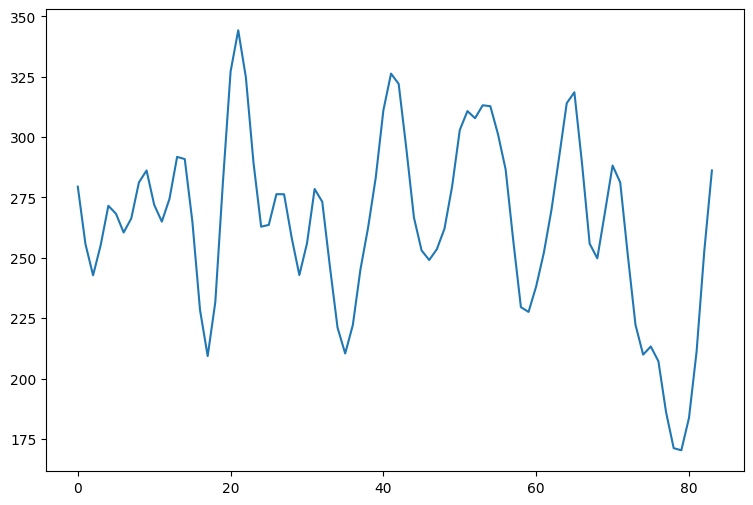

In [9]:
#Sales Viz
df1.Sales.plot(figsize = (9,6))

<Axes: >

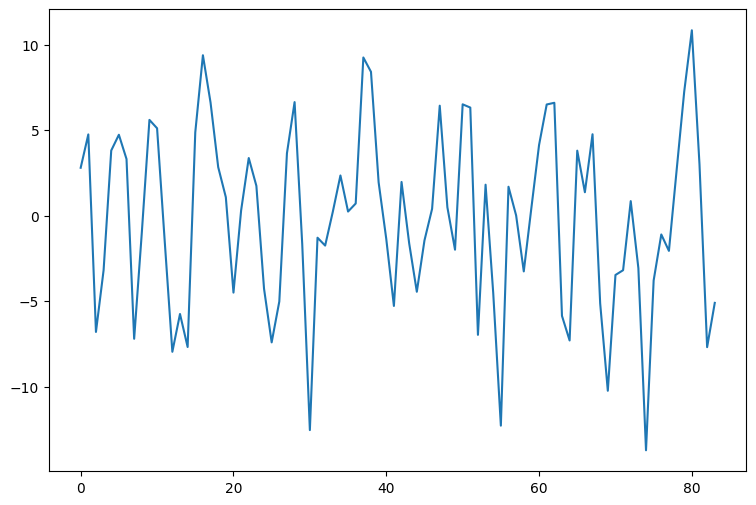

In [10]:
#Adv Viz
df1.Adv.plot(figsize = (9,6))

In [11]:
#Stationarity
from statsmodels.tsa.stattools import adfuller
stationarity = adfuller(df1['Sales'])
print('Augmented Dickey Fuller p-value: %F' % stationarity[1])

Augmented Dickey Fuller p-value: 0.118511


In [12]:
#Stationarity
from statsmodels.tsa.stattools import adfuller
stationarity = adfuller(df1['Adv'])
print('Augmented Dickey Fuller p-value: %F' % stationarity[1])

Augmented Dickey Fuller p-value: 0.000147


In [13]:
#Training and test set
test = 10
training_set = df1.iloc[:-test, :]
test_set = df1.iloc[-test:, :]
test_set

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5
74,209.94,-13.72,-3.07,0.85,-3.19,-3.47,-10.24
75,213.30,-3.79,-13.72,-3.07,0.85,-3.19,-3.47
76,207.19,-1.10,-3.79,-13.72,-3.07,0.85,-3.19
77,186.13,-2.06,-1.10,-3.79,-13.72,-3.07,0.85
78,171.20,2.62,-2.06,-1.10,-3.79,-13.72,-3.07
79,170.33,7.25,2.62,-2.06,-1.10,-3.79,-13.72
80,183.69,10.84,7.25,2.62,-2.06,-1.10,-3.79
81,211.30,3.00,10.84,7.25,2.62,-2.06,-1.10
82,252.66,-7.69,3.00,10.84,7.25,2.62,-2.06
83,286.20,-5.10,-7.69,3.00,10.84,7.25,2.62


In [14]:
training_set

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5
0,279.49,2.80,-1.91,-2.20,-1.19,6.16,3.14
1,255.75,4.75,2.80,-1.91,-2.20,-1.19,6.16
2,242.78,-6.80,4.75,2.80,-1.91,-2.20,-1.19
3,255.34,-3.19,-6.80,4.75,2.80,-1.91,-2.20
4,271.58,3.81,-3.19,-6.80,4.75,2.80,-1.91
...,...,...,...,...,...,...,...
69,268.82,-10.24,-5.13,4.76,1.37,3.80,-7.30
70,288.24,-3.47,-10.24,-5.13,4.76,1.37,3.80
71,281.26,-3.19,-3.47,-10.24,-5.13,4.76,1.37
72,250.92,0.85,-3.19,-3.47,-10.24,-5.13,4.76


**ARIMA & SARIMA (using Auto Arima)**


In [ ]:
# try it out!

**ARIMA and SARIMA (Manual Model Specification)**

In [17]:
# Import the correct ARIMA class
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# try it out!

**ARIMAX Using Auto Arima)**

In [19]:
#Exogenous Variables
train_exog = training_set.iloc[:, 1:]
test_exog = test_set.iloc[:, 1:]
print(train_exog)

      Adv  AdvLag1  AdvLag2  AdvLag3  AdvLag4  AdvLag5
0    2.80    -1.91    -2.20    -1.19     6.16     3.14
1    4.75     2.80    -1.91    -2.20    -1.19     6.16
2   -6.80     4.75     2.80    -1.91    -2.20    -1.19
3   -3.19    -6.80     4.75     2.80    -1.91    -2.20
4    3.81    -3.19    -6.80     4.75     2.80    -1.91
..    ...      ...      ...      ...      ...      ...
69 -10.24    -5.13     4.76     1.37     3.80    -7.30
70  -3.47   -10.24    -5.13     4.76     1.37     3.80
71  -3.19    -3.47   -10.24    -5.13     4.76     1.37
72   0.85    -3.19    -3.47   -10.24    -5.13     4.76
73  -3.07     0.85    -3.19    -3.47   -10.24    -5.13

[74 rows x 6 columns]


In [20]:
print(test_exog)

      Adv  AdvLag1  AdvLag2  AdvLag3  AdvLag4  AdvLag5
74 -13.72    -3.07     0.85    -3.19    -3.47   -10.24
75  -3.79   -13.72    -3.07     0.85    -3.19    -3.47
76  -1.10    -3.79   -13.72    -3.07     0.85    -3.19
77  -2.06    -1.10    -3.79   -13.72    -3.07     0.85
78   2.62    -2.06    -1.10    -3.79   -13.72    -3.07
79   7.25     2.62    -2.06    -1.10    -3.79   -13.72
80  10.84     7.25     2.62    -2.06    -1.10    -3.79
81   3.00    10.84     7.25     2.62    -2.06    -1.10
82  -7.69     3.00    10.84     7.25     2.62    -2.06
83  -5.10    -7.69     3.00    10.84     7.25     2.62


In [ ]:
# try it out!

**ARIMAX (Manual Specification)**

In [ ]:
# try it out!

**Try X= 10 Lags (Gas)**

In [22]:
def lag_arrange(df,name = 'Adv',n_lag = 10):
    # name = 'Gas'
    for i in np.arange(n_lag) + 1:
        # print(i)
        df[name + 'Lag' + str(i)] = df[[name]].shift(i)
    df = df.dropna(how = 'any').reset_index().iloc[:,1:]
    return df

In [23]:
df1 = lag_arrange(df)
df1

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5,AdvLag6,AdvLag7,AdvLag8,AdvLag9,AdvLag10
0,268.27,4.73,3.81,-3.19,-6.80,4.75,2.80,-1.91,-2.20,-1.19,6.16,3.14
1,260.51,3.31,4.73,3.81,-3.19,-6.80,4.75,2.80,-1.91,-2.20,-1.19,6.16
2,266.34,-7.20,3.31,4.73,3.81,-3.19,-6.80,4.75,2.80,-1.91,-2.20,-1.19
3,281.24,-1.01,-7.20,3.31,4.73,3.81,-3.19,-6.80,4.75,2.80,-1.91,-2.20
4,286.19,5.60,-1.01,-7.20,3.31,4.73,3.81,-3.19,-6.80,4.75,2.80,-1.91
...,...,...,...,...,...,...,...,...,...,...,...,...
74,170.33,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19,-3.47,-10.24
75,183.69,10.84,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19,-3.47
76,211.30,3.00,10.84,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19
77,252.66,-7.69,3.00,10.84,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85


In [24]:
#Training and test set
test = 10
training_set = df1.iloc[:-test, :]
test_set = df1.iloc[-test:, :]
test_set.head(10)

,Sales,Adv,AdvLag1,AdvLag2,AdvLag3,AdvLag4,AdvLag5,AdvLag6,AdvLag7,AdvLag8,AdvLag9,AdvLag10
69,209.94,-13.72,-3.07,0.85,-3.19,-3.47,-10.24,-5.13,4.76,1.37,3.80,-7.30
70,213.30,-3.79,-13.72,-3.07,0.85,-3.19,-3.47,-10.24,-5.13,4.76,1.37,3.80
71,207.19,-1.10,-3.79,-13.72,-3.07,0.85,-3.19,-3.47,-10.24,-5.13,4.76,1.37
72,186.13,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19,-3.47,-10.24,-5.13,4.76
73,171.20,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19,-3.47,-10.24,-5.13
74,170.33,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19,-3.47,-10.24
75,183.69,10.84,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19,-3.47
76,211.30,3.00,10.84,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85,-3.19
77,252.66,-7.69,3.00,10.84,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07,0.85
78,286.20,-5.10,-7.69,3.00,10.84,7.25,2.62,-2.06,-1.10,-3.79,-13.72,-3.07


In [25]:
#Exogenous Variables
train_exog = training_set.iloc[:, 1:]
test_exog = test_set.iloc[:, 1:]
print(train_exog)

      Adv  AdvLag1  AdvLag2  AdvLag3  AdvLag4  AdvLag5  AdvLag6  AdvLag7  \
0    4.73     3.81    -3.19    -6.80     4.75     2.80    -1.91    -2.20   
1    3.31     4.73     3.81    -3.19    -6.80     4.75     2.80    -1.91   
2   -7.20     3.31     4.73     3.81    -3.19    -6.80     4.75     2.80   
3   -1.01    -7.20     3.31     4.73     3.81    -3.19    -6.80     4.75   
4    5.60    -1.01    -7.20     3.31     4.73     3.81    -3.19    -6.80   
..    ...      ...      ...      ...      ...      ...      ...      ...   
64 -10.24    -5.13     4.76     1.37     3.80    -7.30    -5.86     6.60   
65  -3.47   -10.24    -5.13     4.76     1.37     3.80    -7.30    -5.86   
66  -3.19    -3.47   -10.24    -5.13     4.76     1.37     3.80    -7.30   
67   0.85    -3.19    -3.47   -10.24    -5.13     4.76     1.37     3.80   
68  -3.07     0.85    -3.19    -3.47   -10.24    -5.13     4.76     1.37   

    AdvLag8  AdvLag9  AdvLag10  
0     -1.19     6.16      3.14  
1     -2.20    -1.19 

In [ ]:
# try it out!